In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from amoc_analysis import data, plotting
from amocatlas import read
from spectra_filtering import analysis, spectra # sonst amocatlas.spectra_filtering


In [2]:
ds = read.mocha()

MOC = ds["MOC"]

Loading 1 MOCHA 26°N dataset(s):
  0. Johns_2023_mht_data_2020_ERA5.zip: No description available



/Users/jakob/Desktop/SS2026/DataAnalysis/.venv/lib/python3.13/site-packages/amocatlas/reader_utils.py:80: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path, **kwargs)


In [3]:
ds

<xarray.Dataset> Size: 121MB
Dimensions:               (TIME: 12202, depth: 307)
Coordinates:
  * TIME                  (TIME) datetime64[ns] 98kB 2004-04-02 ... 2020-12-1...
    DEPTH                 (depth) float64 2kB ...
Dimensions without coordinates: depth
Data variables: (12/20)
    Q_eddy                (TIME) float64 98kB 0.0569 0.05509 ... 0.06124 0.06103
    MHT_EKMAN             (TIME) float64 98kB -0.1455 -0.1618 ... 0.7954 0.8344
    MHT_FC                (TIME) float64 98kB 2.154 2.18 2.203 ... 2.335 2.34
    MHT_GYRE              (TIME) float64 98kB 0.1355 0.1346 ... 0.1034 0.1029
    MHT_INT               (TIME) float64 98kB -1.668 -1.665 ... -1.871 -1.87
    MHT_MO                (TIME) float64 98kB -1.414 -1.408 ... -1.702 -1.697
    ...                    ...
    TRANSPROF_FC          (TIME, depth) float64 30MB ...
    TRANSPROF_FC_MEAN     (depth) float64 2kB ...
    TRANS_EKMAN           (TIME) float64 98kB ...
    TRANS_FC              (TIME) float64 98kB ...
    MOC                   (TIME) float64 98kB ...
    STREAMFUNCTION_Z      (TIME, depth) float64 30MB ...
Attributes: (12/40)
    title:                                 MOCHA Heat Transport Data 3/29/200...
    summary:                               Total heat transport results for t...
    program:                               RAPID
    project:                               RAPID-MOCHA
    license:                               ODC-BY
    acknowledgment:                        Funding source: the US National Sc...
    ...                                    ...
    applied_variable_mapping:              {'time': 'TIME', 'maxmoc': 'MOC', ...
    convert_to_coord:                      z
    variables_to_remove:                   ['day', 'hour', 'julian_day', 'mon...
    principal_investigator_url:            http://www.rsmas.miami.edu/people/...
    methodology reference:                 W.E. Johns, S. Elipot, D.A. Smeed,...
    methodology doi:                       doi: 10.1098/rsta.2022.0188

In [4]:
analysis.seasonal_cycle(MOC['TIME'].values,MOC.values)

,mean,median
1,16.493871,15.942948
2,15.602058,15.700511
3,14.521298,14.668638
4,14.565750,14.778858
5,15.729566,15.805848
6,16.179918,16.153081
7,18.436124,18.218010
8,18.354624,18.263248
9,17.425043,17.230140
10,18.395959,18.821222


In [5]:
analysis.summary_stats(MOC.values)

{'n': 12202,
 'n_missing': np.int64(0),
 'mean': np.float64(16.9166756122395),
 'std': np.float64(4.562324346385208),
 'median': np.float64(17.008903910404673),
 'min': np.float64(-5.0679952580779295),
 'max': np.float64(32.90198198234127),
 'range': np.float64(37.9699772404192)}

In [6]:
freq, psd = spectra.raw_periodogram(MOC, dt_days = 0.5)

In [7]:
spectra.parseval_ratio(MOC,freq,psd)

0.9872806899635366

In [8]:
freq2, psd2 = spectra.welch_psd(MOC,dt_days = 0.5,segment_length=365*5)

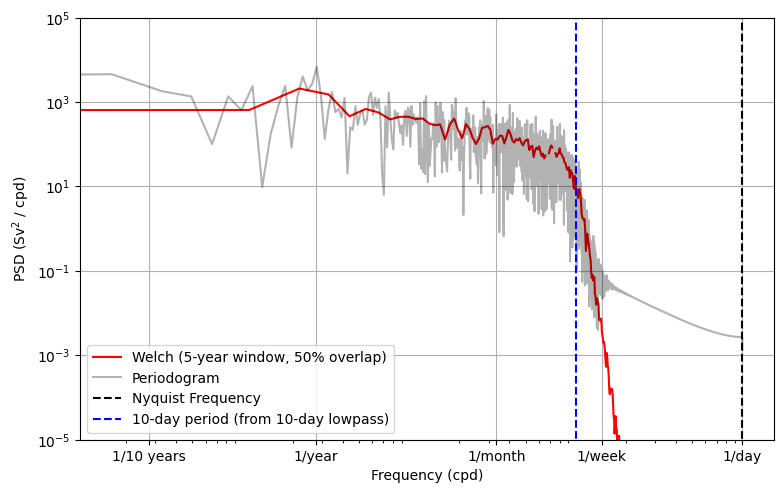

In [9]:
plt.figure(figsize=[8,5])
plt.loglog(freq2,psd2, color = "red", label = "Welch (5-year window, 50% overlap)")
plt.loglog(freq,psd, color = "k", alpha = 0.3, label = "Periodogram")
plt.grid()
#plt.ylim(1e-7,1e4)
plt.xlabel("Frequency (cpd)")
plt.ylabel(f"PSD (Sv$^2$ / cpd)")
plt.tight_layout()
plt.xticks([1,1/7,1/30,1/365,1/3650], ["1/day","1/week","1/month","1/year","1/10 years"])
plt.vlines(1,0,1e5,color = "k", ls = "--", label = "Nyquist Frequency")
plt.vlines(1/10,0,1e5,color = "blue", ls = "--", label = "10-day period (from 10-day lowpass)")
plt.ylim(1e-5,1e5)
plt.legend()
plt.savefig("../figures/mocha_PSD.pdf")
plt.show()

In [10]:
psd2

array([6.62410235e+01, 6.47050519e+02, 2.08878777e+03, 1.50733060e+03,
       4.59995880e+02, 6.86993205e+02, 5.62229986e+02, 3.87270579e+02,
       4.44625177e+02, 4.48813277e+02, 3.96875393e+02, 4.07201659e+02,
       3.12082030e+02, 2.82332686e+02, 2.94912226e+02, 1.29611163e+02,
       2.93772292e+02, 4.04431742e+02, 2.12335557e+02, 1.39542913e+02,
       3.00932227e+02, 2.30297712e+02, 1.37157804e+02, 1.01628476e+02,
       1.38574973e+02, 2.45135359e+02, 2.52847664e+02, 2.71387736e+02,
       2.22838622e+02, 1.03051690e+02, 1.33439631e+02, 1.30353225e+02,
       1.59674569e+02, 1.57372627e+02, 1.04383097e+02, 1.48826044e+02,
       2.18442187e+02, 1.75511115e+02, 1.22742775e+02, 1.09934736e+02,
       1.32597388e+02, 1.22972018e+02, 1.38823729e+02, 1.09446622e+02,
       9.38625875e+01, 1.14860249e+02, 1.25328367e+02, 1.29941674e+02,
       7.29619024e+01, 8.63501100e+01, 9.13687116e+01, 4.97745018e+01,
       7.15212012e+01, 8.28525107e+01, 7.50882442e+01, 8.92980343e+01,
      

In [11]:
for i in np.isfinite(psd2):
    if not i:
        print(":(")

:(
:(
:(
:(
:(
:(
:(
:(
:(
:(


In [12]:
spectra.parseval_ratio(MOC,freq,psd) # sieht gut aus

0.9872806899635366

In [13]:
for x in np.arange(1, len(MOC)//2):
    a = (len(MOC)-x)
    i = 0
    while a > 0:
        a = a - x*0.5
        i = i + 1
    if a == 0:
        print(x,i)
        

1 24402
2 12200
4 6099


In [14]:
for i in np.isfinite(MOC):
    if not i:
        print(":(")